In [2]:
import numpy as np
import matplotlib.pyplot as plt
import uncertainties.unumpy as unp
import uncertainties as uncrt
from uncertainties import ufloat
from uncertainties.unumpy import uarray
from scipy.optimize import curve_fit
import scipy.constants as constants
from uncertainties import ufloat_fromstr
from matplotlib.colors import hsv_to_rgb

In [3]:
N_POINTS=100000
N_RUNS=100

directory="Data\data_broad_nopump\\"

<>:4: SyntaxWarning: invalid escape sequence '\d'
<>:4: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Student\AppData\Local\Temp\ipykernel_2784\3411077584.py:4: SyntaxWarning: invalid escape sequence '\d'
  directory="Data\data_broad_nopump\\"


In [4]:
#Load in the data to an array where the first index is the run and the second(last) index is the sample
data=np.zeros((N_RUNS,N_POINTS))
for i in range(N_RUNS):
    data[i]=np.fromfile(directory+"ch1_{}.bin".format(i),dtype='int8')

calibration=np.zeros((N_RUNS,N_POINTS))
for i in range(N_RUNS):
    calibration[i]=np.fromfile(directory+"ch2_{}.bin".format(i),dtype='int8')

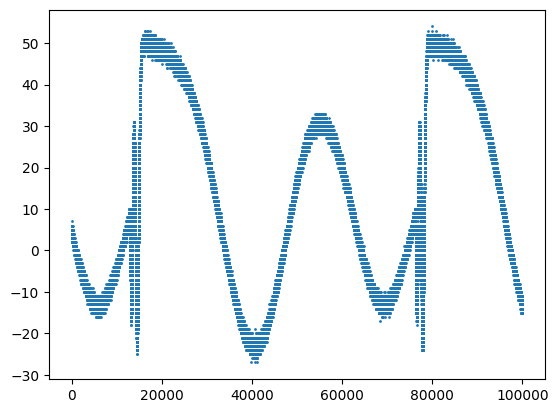

In [5]:

plt.scatter(np.arange(0,N_POINTS),data[0],marker='o',s=1)
plt.show()

In [6]:
GROUP_SIZE=100
N_GROUPS=N_POINTS//GROUP_SIZE

grouped_data=uarray(np.zeros((N_RUNS,N_GROUPS)),np.zeros((N_RUNS,N_GROUPS)))
grouped_calibration=uarray(np.zeros((N_RUNS,N_GROUPS)),np.zeros((N_RUNS,N_GROUPS)))

for run in range(N_RUNS):
    for group in range(N_GROUPS):
        grouped_data[run,group]=ufloat(np.mean(data[run,group*GROUP_SIZE:(group+1)*GROUP_SIZE]),np.std(data[run,group*GROUP_SIZE:(group+1)*GROUP_SIZE],ddof=1)/np.sqrt(GROUP_SIZE))
        grouped_calibration[run,group]=ufloat(np.mean(calibration[run,group*GROUP_SIZE:(group+1)*GROUP_SIZE]),np.std(calibration[run,group*GROUP_SIZE:(group+1)*GROUP_SIZE],ddof=1)/np.sqrt(GROUP_SIZE))

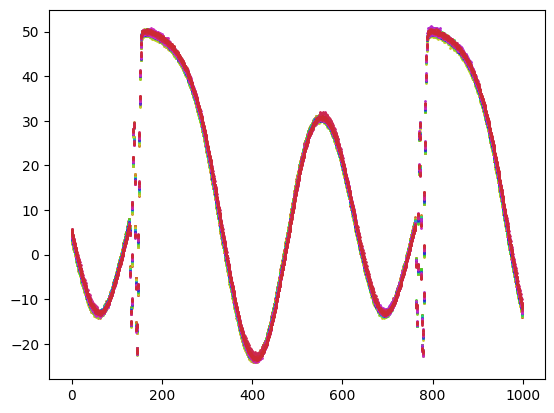

In [ ]:
for i in range(100):
    col=hsv_to_rgb((i/100,0.8,0.8))
    plt.scatter(np.arange(0,N_GROUPS),unp.nominal_values(grouped_data[i]),s=1,color=col)
plt.show()

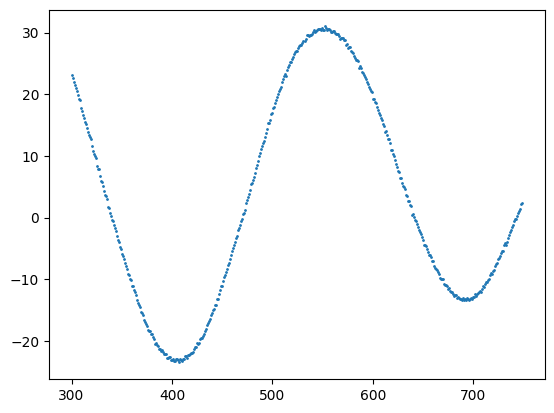

In [8]:
i=30000//GROUP_SIZE
f=75000//GROUP_SIZE
plt.scatter(np.arange(i,f),unp.nominal_values(grouped_data[0,i:f]),marker='o',s=1)
plt.show()

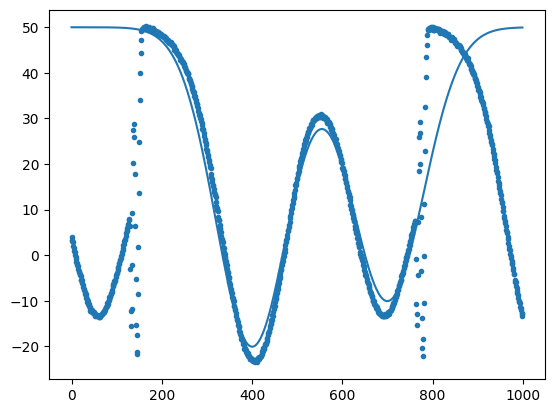

In [9]:
def binorm(t,a1,m1,s1,a2,m2,s2,c):
    return a1*np.exp(-(t-m1)**2/(2*s1**2))+a2*np.exp(-(t-m2)**2/(2*s2**2))+c

p0=[-70,40000/GROUP_SIZE,8000/GROUP_SIZE,-60,70000/GROUP_SIZE,8000/GROUP_SIZE,50]

plt.scatter(np.arange(0,N_GROUPS),unp.nominal_values(grouped_data[0]),marker='.')
plt.plot(binorm(np.arange(0,N_GROUPS),*p0))
plt.show()

In [10]:
popts=np.zeros((N_RUNS,len(p0)))

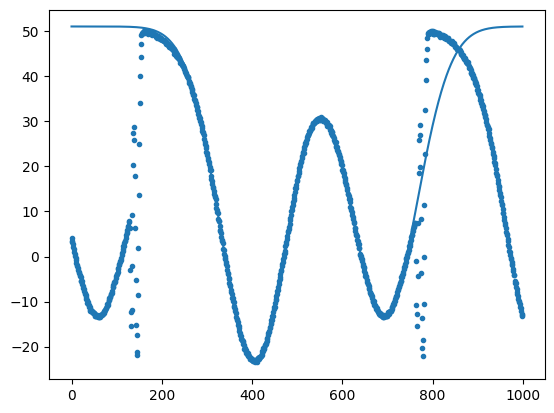

In [11]:
run=unp.nominal_values(grouped_data[0,i:f])
popt,pcov=curve_fit(
        f=binorm,
        xdata=np.arange(i,f),
        ydata=run,
        p0=p0,
        #sigma=unp.std_devs(grouped_calibration[run,i:f]),
        #absolute_sigma=True
    )

plt.scatter(np.arange(0,N_GROUPS),unp.nominal_values(grouped_data[0]),marker='.')
plt.plot(binorm(np.arange(0,N_GROUPS),*popt))
plt.show()



In [12]:
for j,run in enumerate(unp.nominal_values(grouped_data[:,i:f])):
    popt,pcov=curve_fit(
            f=binorm,
            xdata=np.arange(i,f),
            ydata=run,
            p0=p0,
            #sigma=unp.std_devs(grouped_calibration[run,i:f]),
            #absolute_sigma=True
        )

    popts[j]=popt

In [13]:
ps=uarray(np.mean(popts,axis=0),np.std(popts,axis=0,ddof=1)/np.sqrt(N_RUNS))

In [14]:
for p in ps:
    print(p)

-74.29+/-0.05
405.82+/-0.10
73.81+/-0.04
-64.02+/-0.05
693.98+/-0.08
73.19+/-0.04
50.83+/-0.05


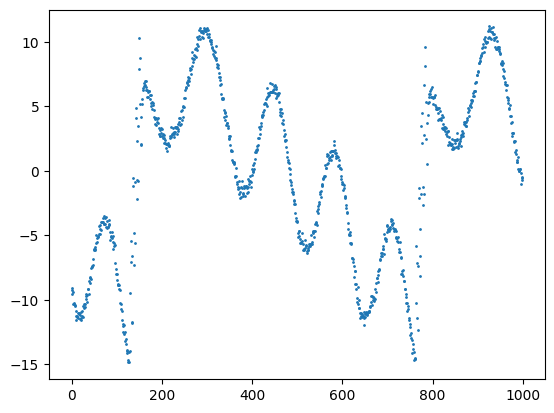

In [15]:
plt.scatter(np.arange(0,N_GROUPS),unp.nominal_values(grouped_calibration[0]),marker='o',s=1)
plt.show()

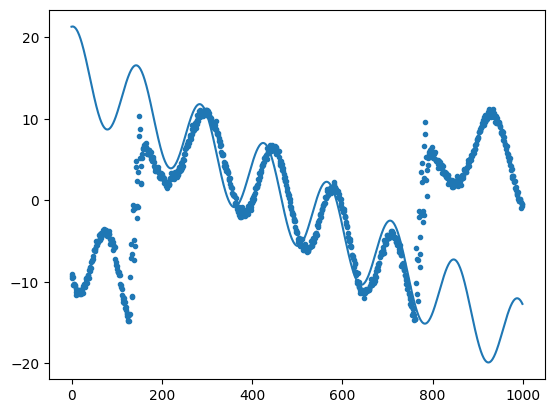

In [16]:
#function to fit, at a guess its the sum of a quadrosoinal plus a quadratic
def fit(t,A,omega,phi_0,C0,C1):
    return A*(np.sin(omega*t+phi_0))+(C1*t+C0)

p0=[5.07502249,  0.044659478*GROUP_SIZE/100,  1.31355333, 16.37899814, -0.0338609*GROUP_SIZE/100]

plt.scatter(np.arange(0,N_GROUPS),unp.nominal_values(grouped_calibration[0]),marker='.')
plt.plot(fit(np.arange(0,N_GROUPS),*p0))
plt.show()

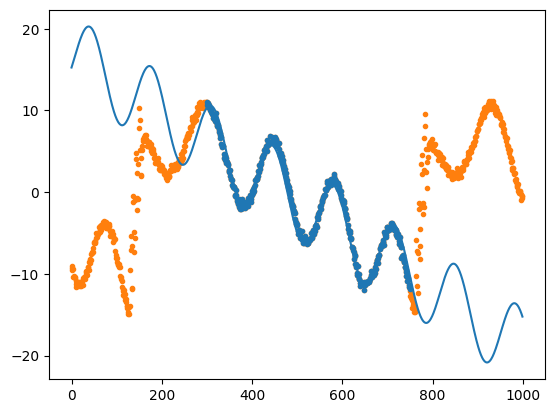

In [17]:
paramiters=uarray(np.zeros((N_RUNS, len(p0))),np.zeros((N_RUNS, len(p0))))


for run in range(N_RUNS):
    popt,pcov=curve_fit(
        f=fit,
        xdata=np.arange(i,f),
        ydata=unp.nominal_values(grouped_calibration[run,i:f]),
        p0=p0,
        #sigma=unp.std_devs(grouped_calibration[run,i:f]),
        #absolute_sigma=True
    )
    paramiters[run]=uncrt.correlated_values(popt,pcov)

plt.scatter(np.arange(0,N_GROUPS),unp.nominal_values(grouped_calibration[0]),marker='.',color='C1')
plt.scatter(np.arange(i,f),unp.nominal_values(grouped_calibration[0,i:f]),marker='.',color='C0')
plt.plot(fit(np.arange(0,N_GROUPS),*unp.nominal_values(paramiters[0])))
plt.savefig("calibration.png")

In [18]:
omega=uarray(
    np.mean(unp.nominal_values(paramiters[:,1])),
    np.std(unp.nominal_values(paramiters[:,1]),ddof=1)#/np.sqrt(N_RUNS)
    )

omegas=unp.nominal_values(paramiters[:,1])

L1=ufloat(0.075,0.003)
L2=ufloat(0.37,0.002)

sweeprate=unp.nominal_values(constants.c*(omega)/(4*np.pi*(L1-L2)))

In [19]:
def d(t):
    return unp.nominal_values(sweeprate*(t-ps[1]))/1000000000

def y(x):
    return (x*80*10**(-6)+33.7800*10**(-3))/(ps[6]*80*10**(-6)+33.7800*10**(-3))

In [20]:
print(1-y(ps[6]+ps[0]),1-y(ps[6]+ps[3]))
print((ps[4]-ps[1])*sweeprate)
print(y(ps[6]))

0.15703+/-0.00010 0.13533+/-0.00012
(-1.0733+/-0.0005)e+09
1.0+/-0


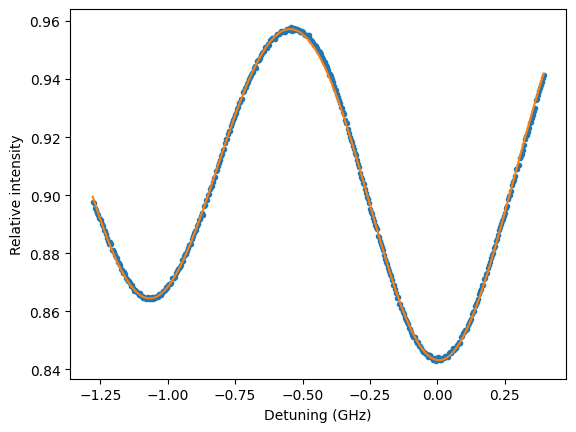

In [21]:
plt.errorbar(d(np.arange(i,f)),unp.nominal_values(y(grouped_data[0,i:f])),yerr=unp.std_devs(y(grouped_data[0,i:f])),marker='.',linestyle='')
plt.plot(d(np.arange(i,f)),unp.nominal_values(y(binorm(np.arange(i,f),*popts[0]))),color='C1',zorder=10)
plt.xlabel("Detuning (GHz)")
plt.ylabel("Relative intensity")
plt.savefig("doppler_broadend_spectrum.png",dpi=600)

In [22]:
sigma_1=ps[2]*sweeprate
sigma_2=ps[5]*sweeprate
print(sigma_1,sigma_2)




(-2.7493+/-0.0014)e+08 (-2.7263+/-0.0014)e+08


In [23]:
print("percentage error in aproximation",(1*10**(9)/(constants.c/(780*10**(-9))))*100)
mr=(sigma_1/sigma_2)**2
mre=86.909180529/84.9117897360
print("mass ratio:",mr)
print("epected:",mre)
print("difference in standard deviations:",(mre-mr).n/mr.s)

percentage error in aproximation 0.0002601799942545586
mass ratio: 1.0169+/-0.0015
epected: 1.0235231267555436
difference in standard deviations: 4.480725296551163


In [24]:
def ufloat_from_sample(sample):
    return ufloat(np.mean(sample),np.std(sample,ddof=1)/np.sqrt(len(sample)))
    

In [25]:
print((ps[2]/ps[5])**2)
#this error is way to low so im going to try calculating it in a different but hopefully concistant way
print(ufloat_from_sample(unp.nominal_values((popts[:,2]/popts[:,5])**2)))

1.0169+/-0.0015
1.0169+/-0.0005


In [26]:
mr=ufloat_from_sample(unp.nominal_values((popts[:,2]/popts[:,5])**2))
print("difference in standard deviations:",(mre-mr).n/mr.s)

difference in standard deviations: 13.543275106306755


In [27]:
ar=ufloat_from_sample(unp.nominal_values(((popts[:,1]*popts[:,2])/(popts[:,4]*popts[:,5]))))
print(ar)
print(27.832/72.172)

0.58970+/-0.00017
0.38563431801806797


In [28]:
f=ufloat(384.230,0.001)*10**12

def T(sigma,m):
    return (m/constants.Boltzmann)*((constants.c/f)*sigma)**2-273.16


In [29]:
print(sigma_1)
print(T(sigma_1,86.909180529*constants.u),"celcius")

#our stnadard deviations are way to broad
#natural broadening?
#collision broadening?

(-2.7493+/-0.0014)e+08
207.8+/-0.5 celcius


In [30]:
fdif=(ps[4]-ps[1])*sweeprate

print("difference in frequency",fdif)
print("coresponding to an energy of",fdif*constants.h)

difference in frequency (-1.0733+/-0.0005)e+09
coresponding to an energy of (-7.1120+/-0.0032)e-25


In [31]:
f85=ufloat_fromstr("384.230406373(14)")*10**12-ufloat_fromstr("1.2648885163(25)")*10**9
f87=ufloat_fromstr("384.2304844685(62)")*10**12-ufloat_fromstr("2.563005979089109(34)")*10**9

print(f87-f85)


(-1.220022+/-0.000015)e+09


In [32]:
sbz=f87-f85-fdif
print(sbz)
print(sbz.n/sbz.s)

(-1.467+/-0.005)e+08
-302.4957508483953
